In [1]:
import torch
print("CUDA:", torch.cuda.is_available())
!nvidia-smi

CUDA: True
Thu Mar 12 03:03:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+------------------------------------

In [2]:
import os, math, random, time
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
from PIL import Image

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

for f in os.listdir("/content/drive/MyDrive"):
    print(f)

chapter 2 thesis.docx
Computer Graphics (1) (2).rar
THESIS AR
Tours-Travels-Management-System-main
Eshop lab_5.docx
Desktop 2021.03.04 - 15.28.39.02.mp4
Desktop 2021.03.18 - 14.13.02.01.mp4
Human Anatomy App Thesis
Untitled form.gform
dec17.rar
Tours-Travels-Management-System - Copy.rar
project mid.zip
project final.zip
WhatsApp Images
Graphics lab (1)
Graphics lab
IMG_1395.JPG
IMG_1186.MOV
paper.docx
Untitled presentation (5).gslides
HCI assignment 01.pdf
Untitled presentation.pptx
17-34684-2.pdf
Internship_Report_Template_[UPDATED].docx
rima
Final _internship report_17-34684-2.pdf
suriya job Cv
100 Essential English Grammar Rules8-22-2020.pdf
REcommendation
AR paper publication
17-2 rag day
recommendation2.docx
REcommendation (1)
f2 visa
Suri's SOP.docx
LOR&SOP (1)
f1 visa
f2 visa (1)
LOR&SOP
Recommendation,TA suriya
atp3
BluethootAttendance
Boom Town SoftwareUpdateOne
c# oop2
InventoryStore
New Unity Project
Tours-Travels-Management-System
MS Project
Software quality testing
RESEARC

In [5]:
PROJECT = "/content/drive/MyDrive/PlantDiseaseProject"

print(os.listdir(PROJECT))

['preprocessing', 'ssl.ipynb', 'data', 'shared_zip_or_raw', 'data_extracted', 'preprocessed', 'student2_dann_fixmatch_epoch_1.pth', 'student2_dann_fixmatch_epoch_2.pth', 'student2_dann_fixmatch_epoch_3.pth', 'student2_dann_fixmatch_epoch_4.pth', 'student2_dann_fixmatch_epoch_5.pth', 'plant_dann_fixmatch_model.ipynb']


In [6]:
# ===============================
# DATASET PATHS
# ===============================

SOURCE_DIR = "/content/drive/MyDrive/PlantDiseaseProject/data/plantvillage"

TARGET_ROOT = "/content/drive/MyDrive/PlantDiseaseProject/data/plantdoc"

TARGET_LABELED_DIR = f"{TARGET_ROOT}/train_labeled"
TARGET_UNLABELED_DIR = f"{TARGET_ROOT}/train_unlabeled"
TARGET_TEST_DIR = f"{TARGET_ROOT}/test"

print("SOURCE:", SOURCE_DIR)
print("TARGET LABELED:", TARGET_LABELED_DIR)
print("TARGET UNLABELED:", TARGET_UNLABELED_DIR)
print("TARGET TEST:", TARGET_TEST_DIR)

SOURCE: /content/drive/MyDrive/PlantDiseaseProject/data/plantvillage
TARGET LABELED: /content/drive/MyDrive/PlantDiseaseProject/data/plantdoc/train_labeled
TARGET UNLABELED: /content/drive/MyDrive/PlantDiseaseProject/data/plantdoc/train_unlabeled
TARGET TEST: /content/drive/MyDrive/PlantDiseaseProject/data/plantdoc/test


In [7]:
import os

classes = os.listdir(SOURCE_DIR)

print("Number of classes:", len(classes))
print("Example classes:", classes[:10])

Number of classes: 15
Example classes: ['Tomato__Tomato_mosaic_virus', 'Tomato__Target_Spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Septoria_leaf_spot', 'Tomato_Leaf_Mold', 'Tomato_Late_blight', 'Tomato_healthy', 'Tomato_Early_blight', 'Tomato_Bacterial_spot']


In [8]:
print("SOURCE exists:", os.path.exists(SOURCE_DIR))
print("TARGET_LABELED exists:", os.path.exists(TARGET_LABELED_DIR))
print("TARGET_UNLABELED exists:", os.path.exists(TARGET_UNLABELED_DIR))
print("TARGET_TEST exists:", os.path.exists(TARGET_TEST_DIR))

SOURCE exists: True
TARGET_LABELED exists: True
TARGET_UNLABELED exists: True
TARGET_TEST exists: True


FixMatch augmentations (weak + strong)

In [9]:
imagenet_norm = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

weak_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    imagenet_norm
])

strong_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply(
        [transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)],
        p=0.8
    ),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    imagenet_norm
])

test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    imagenet_norm
])

label_map

In [10]:
label_map = {
    'Bell_pepper leaf': 'Pepper__bell___healthy',
    'Bell_pepper leaf spot': 'Pepper__bell___Bacterial_spot',
    'Tomato Early blight leaf': 'Tomato_Early_blight',
    'Tomato Septoria leaf spot': 'Tomato_Septoria_leaf_spot',
    'Tomato leaf': 'Tomato_healthy',
    'Tomato leaf bacterial spot': 'Tomato_Bacterial_spot',
    'Tomato leaf late blight': 'Tomato_Late_blight',
    'Tomato leaf mosaic virus': 'Tomato__Tomato_mosaic_virus',
    'Tomato leaf yellow virus': 'Tomato__Tomato_YellowLeaf__Curl_Virus',
    'Tomato mold leaf': 'Tomato_Leaf_Mold',
}

In [11]:
class MappedPlantDoc(Dataset):
    def __init__(self, root, transform, label_map, source_idx_map):
        self.transform = transform
        self.samples = []

        for folder in os.listdir(root):
            if folder in label_map:
                source_folder_name = label_map[folder]
                target_label = source_idx_map[source_folder_name]
                folder_path = os.path.join(root, folder)

                if os.path.isdir(folder_path):
                    for img_name in os.listdir(folder_path):
                        img_path = os.path.join(folder_path, img_name)
                        self.samples.append((img_path, target_label))

        print(f"Loaded {len(self.samples)} valid samples from {root}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        img = self.transform(img)
        return img, label

Datasets paired weak/strong on the SAME target image

In [12]:
class FixMatchTargetDataset(Dataset):

    def __init__(self, root, weak_transform, strong_transform):
        self.base = datasets.ImageFolder(root)
        self.weak_transform = weak_transform
        self.strong_transform = strong_transform

    def __len__(self):
        return len(self.base.samples)

    def __getitem__(self, idx):
        path, _ = self.base.samples[idx]
        img = Image.open(path).convert("RGB")
        xw = self.weak_transform(img)
        xs = self.strong_transform(img)
        return xw, xs

# Source labeled dataset
src_ds = datasets.ImageFolder(SOURCE_DIR, transform=weak_tf)
source_idx_map = src_ds.class_to_idx
num_classes = len(src_ds.classes)
print("num_classes:", num_classes)

# Target unlabeled dataset (FixMatch)
tgt_unlabeled_ds = FixMatchTargetDataset(
    TARGET_UNLABELED_DIR,
    weak_tf,
    strong_tf
)

# Target labeled dataset (mapped)
tgt_labeled_ds = MappedPlantDoc(
    TARGET_LABELED_DIR,
    transform=test_tf,
    label_map=label_map,
    source_idx_map=source_idx_map
)

# Target test dataset (mapped)
tgt_test_ds = MappedPlantDoc(
    TARGET_TEST_DIR,
    transform=test_tf,
    label_map=label_map,
    source_idx_map=source_idx_map
)

batch_size = 32

src_loader = DataLoader(
    src_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

tgt_unlabeled_loader = DataLoader(
    tgt_unlabeled_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

tgt_labeled_loader = DataLoader(
    tgt_labeled_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

tgt_test_loader = DataLoader(
    tgt_test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Source samples:", len(src_ds))
print("Target unlabeled samples:", len(tgt_unlabeled_ds))
print("Target labeled samples:", len(tgt_labeled_ds))
print("Target test samples:", len(tgt_test_ds))

num_classes: 15
Loaded 75 valid samples from /content/drive/MyDrive/PlantDiseaseProject/data/plantdoc/train_labeled
Loaded 86 valid samples from /content/drive/MyDrive/PlantDiseaseProject/data/plantdoc/test
Source samples: 20638
Target unlabeled samples: 2099
Target labeled samples: 75
Target test samples: 86


GRL (Gradient Reversal Layer)

In [13]:
from torch.autograd import Function

class GradReverse(Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None

def grl(x, lambd=1.0):
    return GradReverse.apply(x, lambd)

DANN model (ResNet50 backbone)

In [14]:
class DANNFixMatch(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        feat_dim = m.fc.in_features
        m.fc = nn.Identity()
        self.feature_extractor = m

        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes),
        )

        self.domain_disc = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, 1)
        )

    def forward(self, x, grl_lambda=1.0):
        feats = self.feature_extractor(x)

        if feats.dim() > 2:
            feats = torch.flatten(feats, 1)

        cls_logits = self.classifier(feats)
        dom_logits = self.domain_disc(grl(feats, grl_lambda))
        return cls_logits, dom_logits

model = DANNFixMatch(num_classes=num_classes).to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s]


Loss functions + schedules (DANN + FixMatch)

In [15]:
ce = nn.CrossEntropyLoss()
bce = nn.BCEWithLogitsLoss()

@torch.no_grad()
def pseudo_labels(logits, tau=0.95):
    probs = torch.softmax(logits, dim=1)
    conf, yhat = torch.max(probs, dim=1)
    mask = (conf >= tau).float()
    return yhat.detach(), mask.detach()

def grl_lambda_schedule(step, max_steps):
    p = float(step) / float(max_steps)
    return 2.0 / (1.0 + math.exp(-10 * p)) - 1.0

Training loop
Source supervised classification

Target FixMatch consistency

Domain adversarial loss (source vs target)



In [16]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

epochs = 5
tau = 0.90
lambda_domain = 0.5
lambda_fix = 1.0

steps_per_epoch = min(len(src_loader), len(tgt_unlabeled_loader))
max_steps = epochs * steps_per_epoch

global_step = 0
best_loss = float("inf")

for epoch in range(1, epochs + 1):
    model.train()
    running = {"cls": 0.0, "dom": 0.0, "fix": 0.0, "tot": 0.0, "accept": 0.0}

    src_iter = iter(src_loader)
    tgt_iter = iter(tgt_unlabeled_loader)

    for step in range(steps_per_epoch):
        xs, ys = next(src_iter)              # source labeled
        xw, xstrong = next(tgt_iter)         # target unlabeled: weak + strong

        xs, ys = xs.to(device), ys.to(device)
        xw = xw.to(device)
        xstrong = xstrong.to(device)

        grl_l = grl_lambda_schedule(global_step, max_steps)

        # Source branch
        src_cls_logits, src_dom_logits = model(xs, grl_lambda=grl_l)
        loss_cls = ce(src_cls_logits, ys)

        # Target unlabeled branch (FixMatch)
        tgt_w_logits, tgt_w_dom_logits = model(xw, grl_lambda=grl_l)
        yhat, mask = pseudo_labels(tgt_w_logits.detach(), tau=tau)

        tgt_s_logits, _ = model(xstrong, grl_lambda=grl_l)
        loss_fix = (F.cross_entropy(tgt_s_logits, yhat, reduction="none") * mask).mean()

        # Domain loss
        dom_src = torch.zeros((xs.size(0), 1), device=device)
        dom_tgt = torch.ones((xw.size(0), 1), device=device)

        loss_dom = 0.5 * (
            bce(src_dom_logits, dom_src) +
            bce(tgt_w_dom_logits, dom_tgt)
        )

        # Total loss
        loss = loss_cls + lambda_domain * loss_dom + lambda_fix * loss_fix

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        running["cls"] += float(loss_cls.item())
        running["dom"] += float(loss_dom.item())
        running["fix"] += float(loss_fix.item())
        running["tot"] += float(loss.item())
        running["accept"] += float(mask.mean().item())

        global_step += 1

        if (step + 1) % 50 == 0:
            n = step + 1
            print(
                f"Epoch {epoch}/{epochs} Step {step+1}/{steps_per_epoch} | "
                f"cls {running['cls']/n:.3f} dom {running['dom']/n:.3f} "
                f"fix {running['fix']/n:.3f} tot {running['tot']/n:.3f} "
                f"| pseudo-accept {running['accept']/n:.2f}"
            )

    n = steps_per_epoch
    epoch_loss = running["tot"] / n

    print(
        f"Epoch {epoch} done | cls {running['cls']/n:.3f} "
        f"dom {running['dom']/n:.3f} fix {running['fix']/n:.3f} "
        f"tot {epoch_loss:.3f} | pseudo-accept {running['accept']/n:.2f}"
    )

    # Save checkpoint each epoch
    ckpt_path = f"/content/drive/MyDrive/PlantDiseaseProject/student2_dann_fixmatch_epoch_{epoch}.pth"
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "classes": src_ds.classes,
        "num_classes": num_classes,
        "tau": tau,
        "lambda_domain": lambda_domain,
        "lambda_fix": lambda_fix,
    }, ckpt_path)
    print("Saved:", ckpt_path)

    # Save best model
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_ckpt_path = "/content/drive/MyDrive/PlantDiseaseProject/student2_dann_fixmatch_best.pth"
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "classes": src_ds.classes,
            "num_classes": num_classes,
            "tau": tau,
            "lambda_domain": lambda_domain,
            "lambda_fix": lambda_fix,
        }, best_ckpt_path)
        print("Saved best model:", best_ckpt_path)

Epoch 1/5 Step 50/65 | cls 1.424 dom 0.571 fix 0.007 tot 1.717 | pseudo-accept 0.01
Epoch 1 done | cls 1.216 dom 0.575 fix 0.020 tot 1.523 | pseudo-accept 0.02
Saved: /content/drive/MyDrive/PlantDiseaseProject/student2_dann_fixmatch_epoch_1.pth
Saved best model: /content/drive/MyDrive/PlantDiseaseProject/student2_dann_fixmatch_best.pth
Epoch 2/5 Step 50/65 | cls 0.397 dom 0.651 fix 0.102 tot 0.824 | pseudo-accept 0.15
Epoch 2 done | cls 0.376 dom 0.625 fix 0.115 tot 0.804 | pseudo-accept 0.19
Saved: /content/drive/MyDrive/PlantDiseaseProject/student2_dann_fixmatch_epoch_2.pth
Saved best model: /content/drive/MyDrive/PlantDiseaseProject/student2_dann_fixmatch_best.pth
Epoch 3/5 Step 50/65 | cls 0.301 dom 0.626 fix 0.114 tot 0.728 | pseudo-accept 0.37
Epoch 3 done | cls 0.297 dom 0.604 fix 0.123 tot 0.722 | pseudo-accept 0.38
Saved: /content/drive/MyDrive/PlantDiseaseProject/student2_dann_fixmatch_epoch_3.pth
Saved best model: /content/drive/MyDrive/PlantDiseaseProject/student2_dann_fixm

Evaluation

In [17]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

Load the best saved checkpoint

In [19]:
CKPT_PATH = "/content/drive/MyDrive/PlantDiseaseProject/student2_dann_fixmatch_best.pth"

checkpoint = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state"])

print("Loaded checkpoint from epoch:", checkpoint["epoch"])

Loaded checkpoint from epoch: 5


In [20]:
def evaluate_model(model, loader, device, source_idx_map):
    model.eval()

    all_preds = []
    all_labels = []

    inv_map = {v: k for k, v in source_idx_map.items()}

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images, grl_lambda=0.0)

            # DANN model returns (class_logits, domain_logits)
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    unique_labels = np.unique(all_labels)
    class_names = [inv_map[i] for i in unique_labels]

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    print(f"Accuracy: {acc*100:.2f}%")
    print(f"Macro F1: {macro_f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        all_labels,
        all_preds,
        labels=unique_labels,
        target_names=class_names,
        zero_division=0
    ))

    cm = confusion_matrix(all_labels, all_preds, labels=unique_labels)

    return acc, macro_f1, cm, class_names

Run evaluation on test loader

In [26]:
acc, macro_f1, cm, class_names = evaluate_model(
    model,
    tgt_test_loader,
    device,
    source_idx_map
)

Accuracy: 26.74%
Macro F1: 0.2012

Classification Report:
                                       precision    recall  f1-score   support

        Pepper__bell___Bacterial_spot       0.43      0.33      0.38         9
               Pepper__bell___healthy       0.75      0.38      0.50         8
                Tomato_Bacterial_spot       0.00      0.00      0.00         9
                  Tomato_Early_blight       0.14      0.11      0.12         9
                   Tomato_Late_blight       0.25      0.40      0.31        10
                     Tomato_Leaf_Mold       0.25      0.33      0.29         6
            Tomato_Septoria_leaf_spot       0.86      0.55      0.67        11
Tomato__Tomato_YellowLeaf__Curl_Virus       0.00      0.00      0.00         6
          Tomato__Tomato_mosaic_virus       1.00      0.10      0.18        10
                       Tomato_healthy       0.38      0.38      0.38         8

                            micro avg       0.32      0.27      0.29   

Run evaluation on your test loader

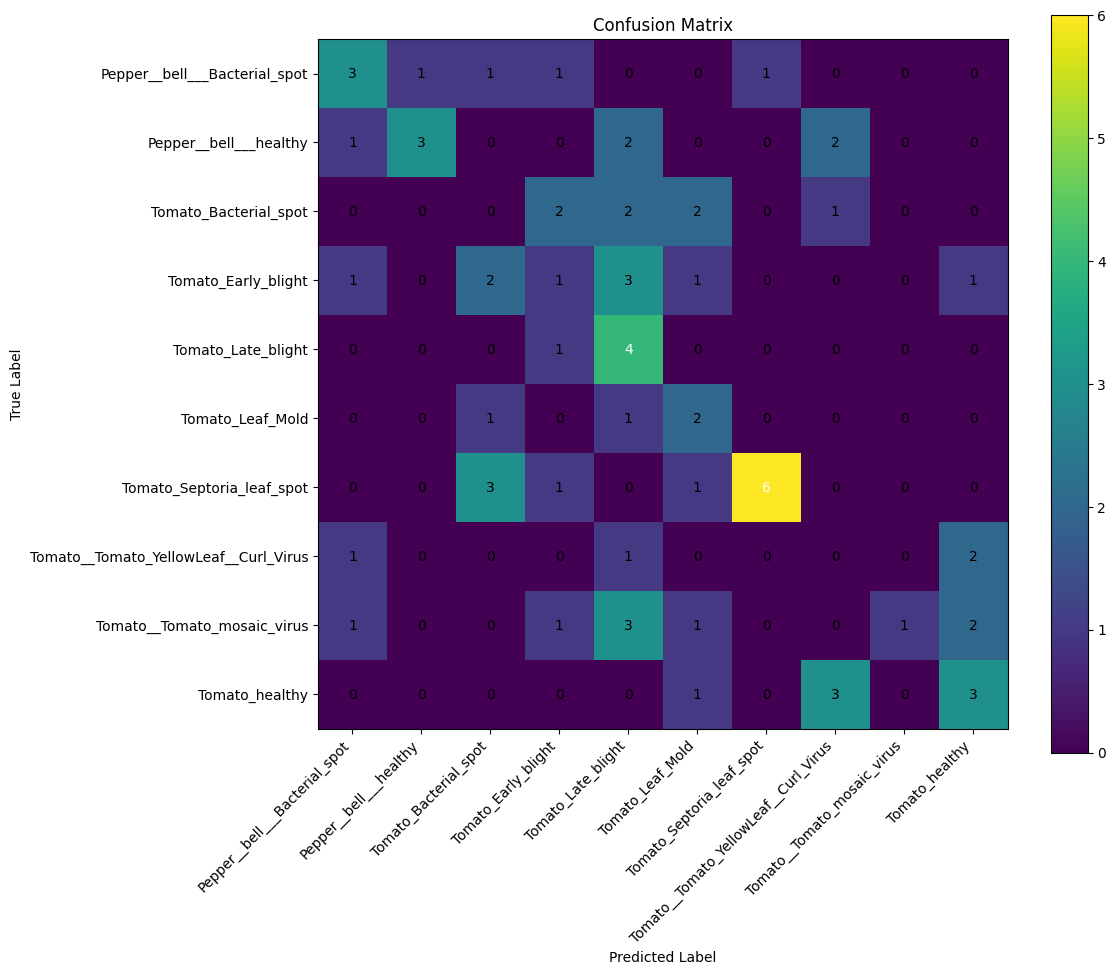

In [27]:
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(cm, interpolation="nearest")
fig.colorbar(im, ax=ax)

ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

thresh = cm.max() / 2 if cm.size > 0 else 0

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, format(cm[i, j], "d"),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.tight_layout()
plt.show()

Save confusion matrix plot to Drive

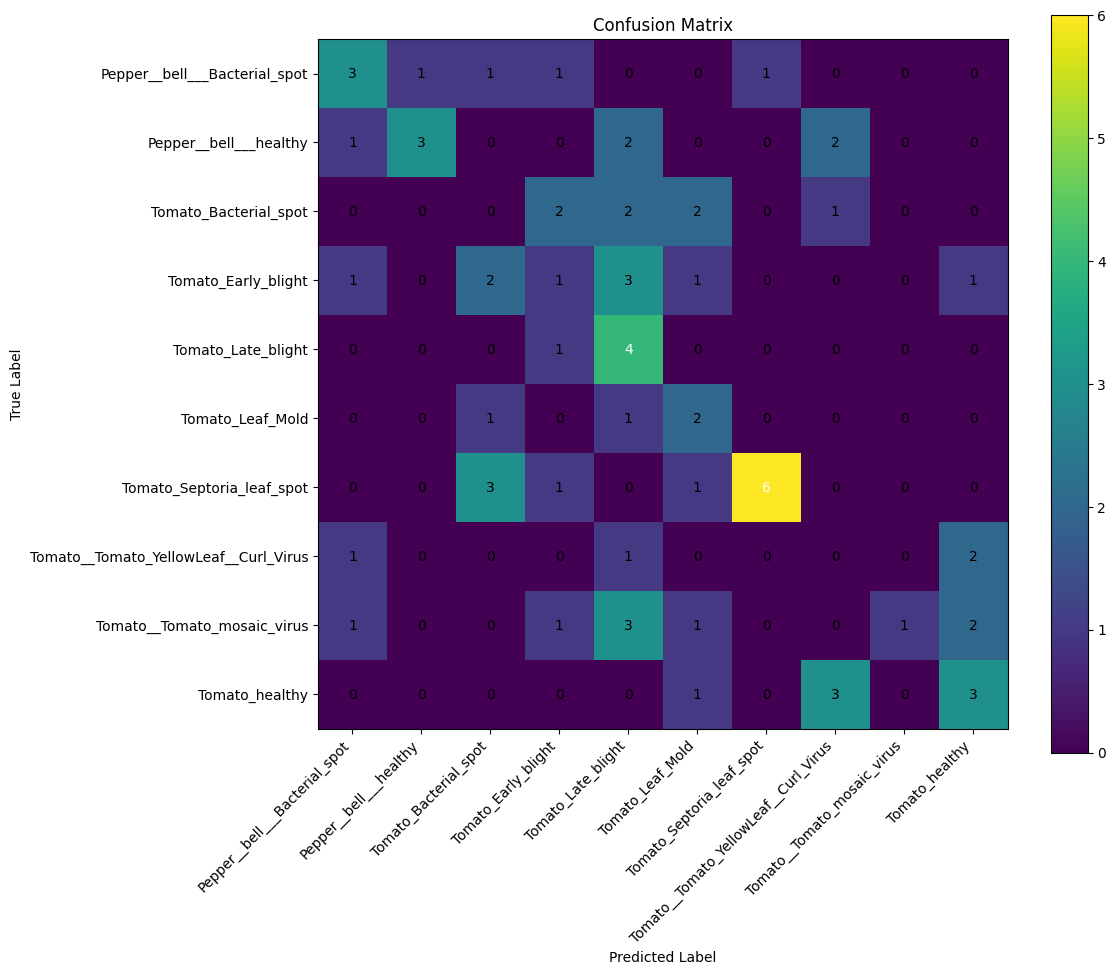

Saved confusion matrix to: /content/drive/MyDrive/PlantDiseaseProject/confusion_matrix_best.png


In [29]:
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(cm, interpolation="nearest")
fig.colorbar(im, ax=ax)

ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

thresh = cm.max() / 2 if cm.size > 0 else 0

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, format(cm[i, j], "d"),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.tight_layout()

save_path = "/content/drive/MyDrive/PlantDiseaseProject/confusion_matrix_best.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix to:", save_path)

Save final metrics to a text file

In [30]:
result_path = "/content/drive/MyDrive/PlantDiseaseProject/final_metrics.txt"

with open(result_path, "w") as f:
    f.write(f"Best checkpoint epoch: {checkpoint['epoch']}\n")
    f.write(f"Accuracy: {acc*100:.2f}%\n")
    f.write(f"Macro F1: {macro_f1:.4f}\n")

print("Saved metrics to:", result_path)

Saved metrics to: /content/drive/MyDrive/PlantDiseaseProject/final_metrics.txt


Compare all epochs

In [32]:
epoch_results = []

for ep in range(1, 6):
    ckpt_path = f"/content/drive/MyDrive/PlantDiseaseProject/student2_dann_fixmatch_epoch_{ep}.pth"
    checkpoint = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])

    acc, macro_f1, _, _ = evaluate_model(model, tgt_test_loader, device, source_idx_map)
    epoch_results.append((ep, acc, macro_f1))

print("\nEpoch-wise Results:")
for ep, acc, macro_f1 in epoch_results:
    print(f"Epoch {ep}: Accuracy={acc*100:.2f}% | Macro F1={macro_f1:.4f}")

Accuracy: 25.58%
Macro F1: 0.1680

Classification Report:
                                       precision    recall  f1-score   support

        Pepper__bell___Bacterial_spot       0.29      0.22      0.25         9
               Pepper__bell___healthy       0.60      0.75      0.67         8
                Tomato_Bacterial_spot       0.00      0.00      0.00         9
                  Tomato_Early_blight       0.50      0.11      0.18         9
                   Tomato_Late_blight       0.25      0.10      0.14        10
                     Tomato_Leaf_Mold       0.33      0.17      0.22         6
            Tomato_Septoria_leaf_spot       0.36      0.73      0.48        11
Tomato__Tomato_YellowLeaf__Curl_Virus       0.07      0.17      0.10         6
          Tomato__Tomato_mosaic_virus       0.00      0.00      0.00        10
                       Tomato_healthy       0.40      0.25      0.31         8

                            micro avg       0.31      0.26      0.28   